First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product 

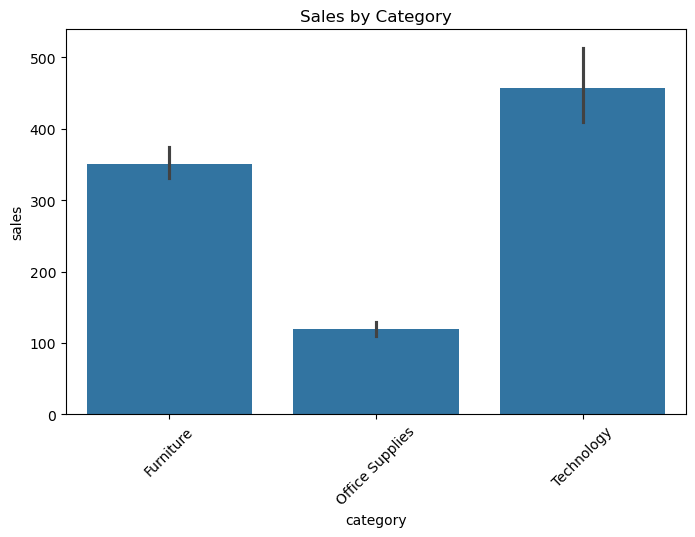

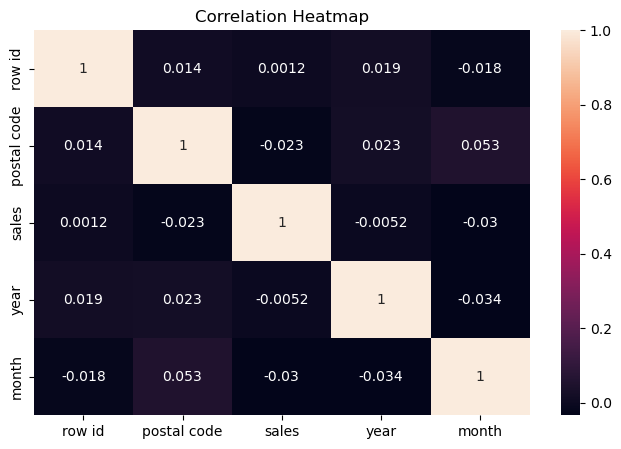


Cleaned dataset saved as 'cleaned_data.csv'

--- BASIC INSIGHTS ---
Average values:
 row id          4900.500000
postal code    55295.655714
sales            230.769059
year            2016.728467
month              6.452892
dtype: float64
Total rows: 9800


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv(r"C:\Users\indhu\Downloads\Dataset\train.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns in dataset:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

df.columns = df.columns.str.strip().str.lower()

print("\nCleaned Column Names:")
print(df.columns)

df.ffill(inplace=True)
df.bfill(inplace=True)

df.drop_duplicates(inplace=True)

if 'profit' in df.columns and 'sales' in df.columns:
    df['profit margin'] = df['profit'] / df['sales']
else:
    print("Skipping profit margin (columns not found)")

if 'order date' in df.columns:
    df['order date'] = pd.to_datetime(df['order date'], errors='coerce')
    df['year'] = df['order date'].dt.year
    df['month'] = df['order date'].dt.month
else:
    print("No date column found, skipping date features")

numeric_cols = df.select_dtypes(include=np.number).columns

if 'category' in df.columns and 'sales' in df.columns:
    sales_by_category = df.groupby('category')['sales'].sum()
    print("\nSales by Category:\n", sales_by_category)
else:
    print("Skipping category analysis")

if 'category' in df.columns and 'sales' in df.columns:
    plt.figure()
    sns.barplot(x='category', y='sales', data=df)
    plt.title("Sales by Category")
    plt.xticks(rotation=45)
    plt.show()

if len(numeric_cols) > 1:
    plt.figure()
    sns.heatmap(df[numeric_cols].corr(), annot=True)
    plt.title("Correlation Heatmap")
    plt.show()
    
df.to_csv("cleaned_data.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_data.csv'")

print("\n--- BASIC INSIGHTS ---")

if len(numeric_cols) > 0:
    print("Average values:\n", df[numeric_cols].mean())

print("Total rows:", len(df))